(178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64


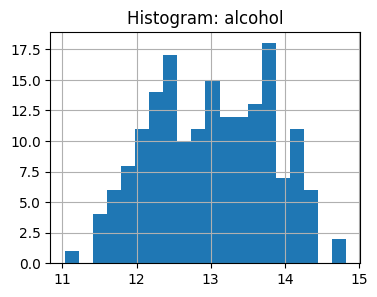

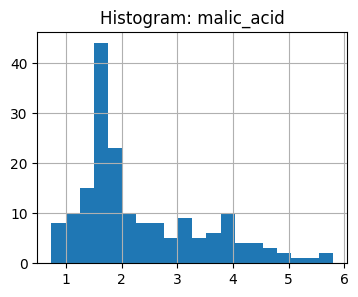

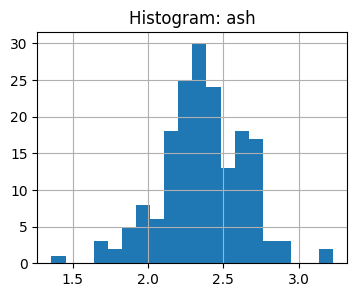

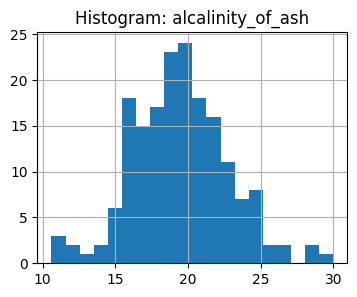

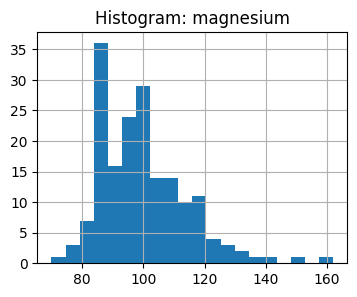

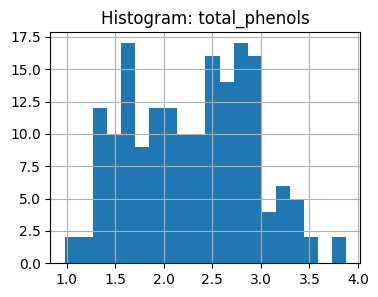

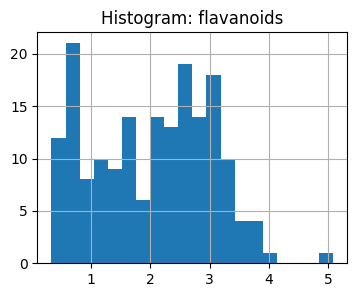

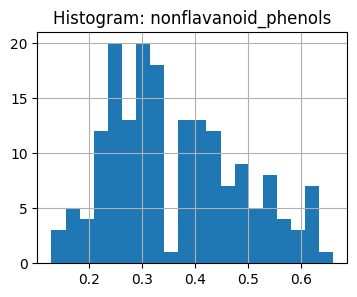

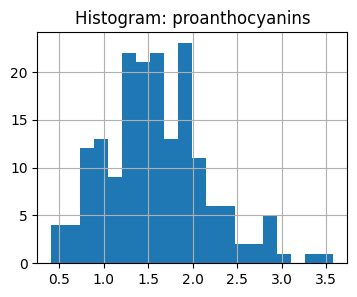

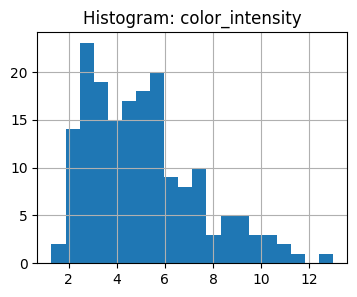

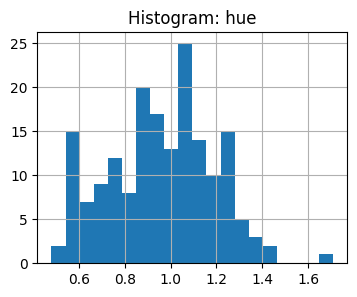

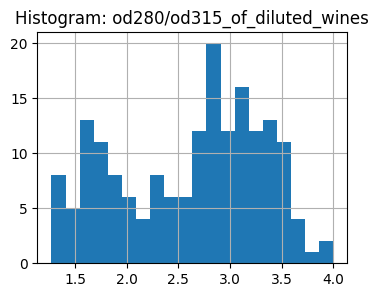

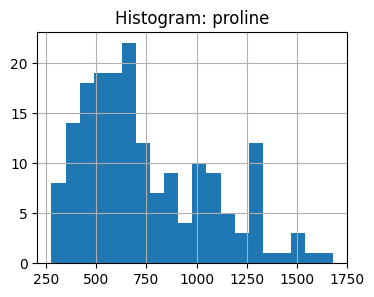

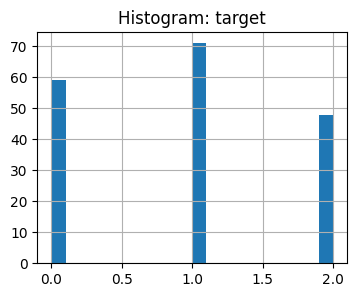

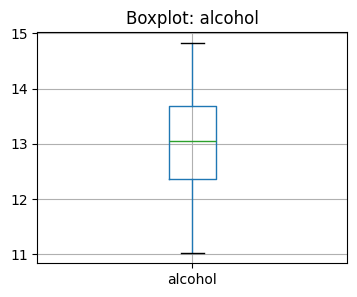

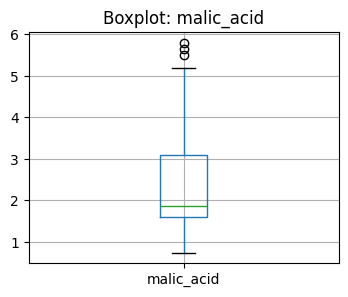

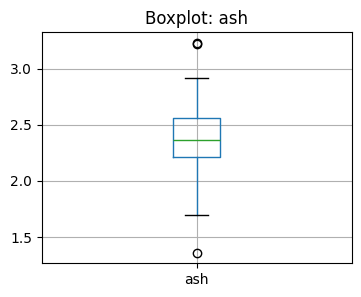

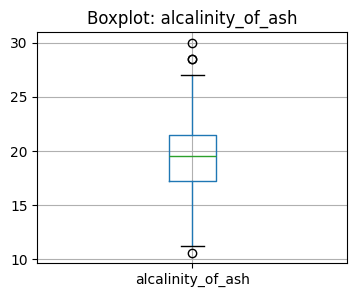

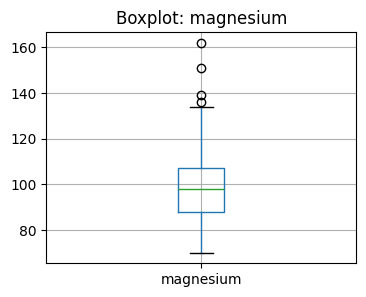

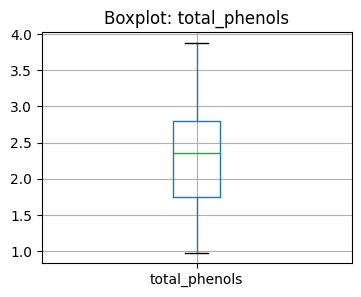

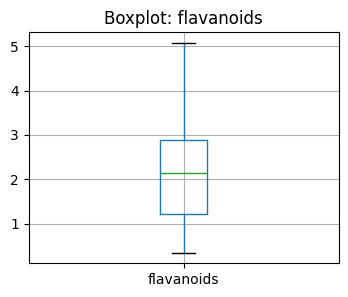

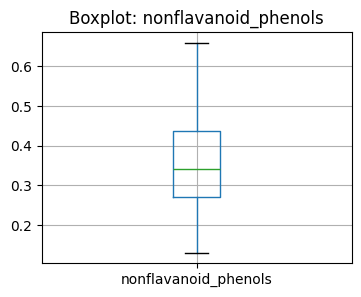

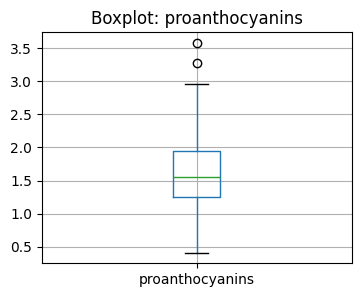

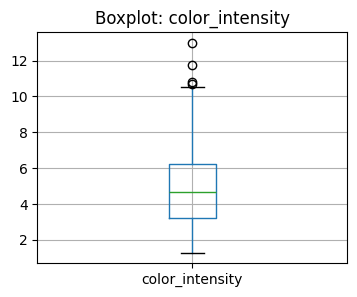

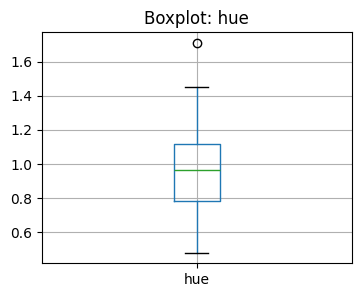

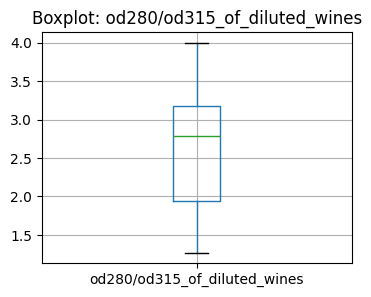

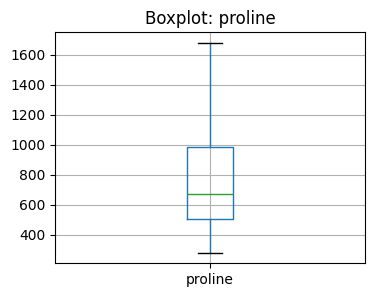

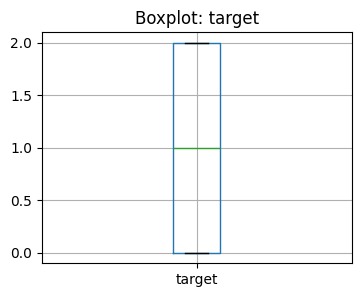

                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   
target                       -0.328222    0.437776 -0.049643   

                              alcalinit

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix

wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

print(df.shape)
print(df.info())
print(df.describe(include='all'))
print(df.isna().sum())

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(4, 3))
    df[col].hist(bins=20)
    plt.title(f'Histogram: {col}')
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(4, 3))
    df.boxplot(column=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

corr = df.corr(numeric_only=True)
print(corr)

data = df.copy()
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

cat_cols = data.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    data[col] = data[col].fillna('brak_danych')

data_encoded = pd.get_dummies(data, drop_first=True)

X_reg = data_encoded.drop('alcohol', axis=1)
y_reg = data_encoded['alcohol']

scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

mse = mean_squared_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
print(f"Regresja - MSE: {mse}, MAE: {mae}")

df_clf = data_encoded[data_encoded['target'].isin([0, 1])]
X_clf = df_clf.drop('target', axis=1)
y_clf = df_clf['target']

scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

acc = accuracy_score(y_test_c, y_pred_c)
cm = confusion_matrix(y_test_c, y_pred_c)
print(f"Klasyfikacja - Accuracy: {acc}")
print(cm)